In [40]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score,KFold,GroupKFold, RandomizedSearchCV, cross_validate, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn. compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from scipy.stats import spearmanr

**LOADING ALL THE DATASETS**

In [41]:
from google.colab import files
uploaded=files.upload()

Saving Cell_Lines_Details.xlsx to Cell_Lines_Details (1).xlsx
Saving Compounds-annotation.csv to Compounds-annotation (1).csv
Saving GDSC_DATASET.csv to GDSC_DATASET (1).csv
Saving GDSC2-dataset.csv to GDSC2-dataset (1).csv


In [42]:
gdsc=pd.read_csv("GDSC_DATASET.csv") #main dataset
gdsc

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242030,1659928,SNU-175,COREAD,2499,N-acetyl cysteine,10.127082,0.976746,0.156872,large_intestine,large_intestine,COAD/READ,MSI-H,R,Suspension,Y,Y,Y,Metabolism,Metabolism
242031,1660034,SNU-407,COREAD,2499,N-acetyl cysteine,8.576377,0.913378,-1.626959,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,Metabolism,Metabolism
242032,1660035,SNU-61,COREAD,2499,N-acetyl cysteine,10.519636,0.975001,0.608442,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent,Y,Y,Y,Metabolism,Metabolism
242033,1674021,SNU-C5,COREAD,2499,N-acetyl cysteine,10.694579,0.969969,0.809684,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,Metabolism,Metabolism


In [43]:
gdsc2=pd.read_csv("GDSC2-dataset.csv") #drug response data
gdsc2 #different number of rows in gdsc and gdsc2

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,684059,ES7,SIDM00269,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,684062,EW-11,SIDM00203,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000100,0.1,-3.741991,0.734047,0.128059,-0.807232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242031,GDSC2,343,16188242,1659928,SNU-175,SIDM00216,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.127082,0.976746,0.074498,0.156872
242032,GDSC2,343,16188695,1660034,SNU-407,SIDM00214,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,8.576377,0.913378,0.057821,-1.626959
242033,GDSC2,343,16188953,1660035,SNU-61,SIDM00194,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.519636,0.975001,0.058090,0.608442
242034,GDSC2,343,16189493,1674021,SNU-C5,SIDM00498,COREAD,2499,N-acetyl cysteine,Metabolism,Metabolism,1101,Y,2.001054,2000.0,10.694579,0.969969,0.101013,0.809684


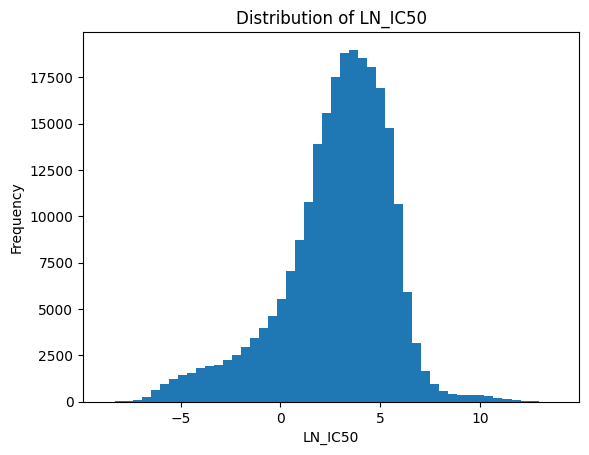

In [44]:
plt.hist(gdsc["LN_IC50"].dropna(), bins=50)
plt.xlabel("LN_IC50")
plt.ylabel("Frequency")
plt.title("Distribution of LN_IC50")
plt.show()

In [45]:
cell_lines=pd.read_excel("Cell_Lines_Details.xlsx") #cell line details
cell_lines

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Sample Name,COSMIC identifier,Whole Exome Sequencing (WES),Copy Number Alterations (CNA),Gene Expression,Methylation,Drug\nResponse,GDSC\nTissue descriptor 1,GDSC\nTissue\ndescriptor 2,Cancer Type\n(matching TCGA label),Microsatellite \ninstability Status (MSI),Screen Medium,Growth Properties
0,A253,906794.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,NaN,MSS/MSI-L,D/F12,Adherent
1,BB30-HNC,753531.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent
2,BB49-HNC,753532.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent
3,BHY,753535.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent
4,BICR10,1290724.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent
...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,KP-2,1298218.0,Y,N,Y,N,Y,pancreas,pancreas,PAAD,NaN,D/F12,Adherent
998,KO52,1330932.0,Y,Y,N,N,N,leukemia,acute_myeloid_leukaemia,LAML,MSS/MSI-L,D/F12,NaN
999,SC-1,1331030.0,Y,Y,N,N,N,lymphoma,B_cell_lymphoma,DLBC,MSS/MSI-L,R,NaN
1000,U-CH2,1503373.0,Y,Y,N,N,N,bone,bone_other,NaN,MSS/MSI-L,D/F12,Adherent


In [46]:
cell_lines = cell_lines.rename(columns={'COSMIC identifier': 'COSMIC_ID', 'Sample Name': 'CELL_LINE_NAME' ,
                                                'GDSC\nTissue descriptor 1':'GDSC Tissue descriptor 1',
                                                'GDSC\nTissue\ndescriptor 2':'GDSC Tissue descriptor 2',
                                                'Cancer Type\n(matching TCGA label)':'Cancer Type (matching TCGA label)',
                                                'Microsatellite \ninstability Status (MSI)':'MSI',
                                                'Whole Exome Sequencing (WES)': 'WES',
                                                'Copy Number Alterations (CNA)': 'CNA'
                                               })
cell_lines

,CELL_LINE_NAME,COSMIC_ID,WES,CNA,Gene Expression,Methylation,Drug\nResponse,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),MSI,Screen Medium,Growth Properties
0,A253,906794.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,NaN,MSS/MSI-L,D/F12,Adherent
1,BB30-HNC,753531.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent
2,BB49-HNC,753532.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent
3,BHY,753535.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent
4,BICR10,1290724.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent
...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,KP-2,1298218.0,Y,N,Y,N,Y,pancreas,pancreas,PAAD,NaN,D/F12,Adherent
998,KO52,1330932.0,Y,Y,N,N,N,leukemia,acute_myeloid_leukaemia,LAML,MSS/MSI-L,D/F12,NaN
999,SC-1,1331030.0,Y,Y,N,N,N,lymphoma,B_cell_lymphoma,DLBC,MSS/MSI-L,R,NaN
1000,U-CH2,1503373.0,Y,Y,N,N,N,bone,bone_other,NaN,MSS/MSI-L,D/F12,Adherent


In [47]:
compounds=pd.read_csv("Compounds-annotation.csv") #drug information
compounds

,DRUG_ID,SCREENING_SITE,DRUG_NAME,SYNONYMS,TARGET,TARGET_PATHWAY
0,1,MGH,Erlotinib,"Tarceva, RG-1415, CP-358774, OSI-774, Ro-50823...",EGFR,EGFR signaling
1,3,MGH,Rapamycin,"AY-22989, Sirolimus, WY-090217, Torisel, Rapamune",MTORC1,PI3K/MTOR signaling
2,5,MGH,Sunitinib,"Sutent, Sunitinib Malate, SU-11248","PDGFR, KIT, VEGFR, FLT3, RET, CSF1R",RTK signaling
3,6,MGH,PHA-665752,"PHA665752, PHA 665752",MET,RTK signaling
4,9,MGH,MG-132,"LLL cpd, MG 132, MG132","Proteasome, CAPN1",Protein stability and degradation
...,...,...,...,...,...,...
616,2362,SANGER,THR-103,WIMM synthesis,Mutant RAS,PI3K/MTOR signaling
617,2438,SANGER,ascorbate (vitamin C),back-up solution from YWKim,anti-oxidant proteins,Other
618,2439,SANGER,glutathione,"G6013, sigma",anti-oxidant proteins,Other
619,2498,SANGER,alpha-lipoic acid,aLA,Metabolism,Metabolism


**EXPLORATORY DATA ANALYSIS**

In [48]:
print("gdsc",gdsc.shape)
print("gdsc2",gdsc2.shape)
print("cell lines",cell_lines.shape)
print("compounds",compounds.shape)


gdsc (242035, 19)
gdsc2 (242036, 19)
cell lines (1002, 13)
compounds (621, 6)


In [49]:
print("gdsc",list(gdsc.columns))
print("gdsc2",list(gdsc2.columns))
print("cell lines",list(cell_lines.columns))
print("compounds",list(compounds.columns))


gdsc ['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)', 'Microsatellite instability Status (MSI)', 'Screen Medium', 'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET', 'TARGET_PATHWAY']
gdsc2 ['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'COSMIC_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'COMPANY_ID', 'WEBRELEASE', 'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE']
cell lines ['CELL_LINE_NAME', 'COSMIC_ID', 'WES', 'CNA', 'Gene Expression', 'Methylation', 'Drug\nResponse', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)', 'MSI', 'Screen Medium', 'Growth Properties']
compounds ['DRUG_ID', 'SCREENING_SITE', 'DRUG_NAME', 'SYNONYMS', 'TARGET', 'TARGET_PATHWAY']


In [50]:
print("gdsc",gdsc.info())
print("gdsc2",gdsc2.info())
print("cell lines",cell_lines.info())
print("compounds",compounds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242035 entries, 0 to 242034
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   COSMIC_ID                                242035 non-null  int64  
 1   CELL_LINE_NAME                           242035 non-null  object 
 2   TCGA_DESC                                240968 non-null  object 
 3   DRUG_ID                                  242035 non-null  int64  
 4   DRUG_NAME                                242035 non-null  object 
 5   LN_IC50                                  242035 non-null  float64
 6   AUC                                      242035 non-null  float64
 7   Z_SCORE                                  242035 non-null  float64
 8   GDSC Tissue descriptor 1                 232669 non-null  object 
 9   GDSC Tissue descriptor 2                 232669 non-null  object 
 10  Cancer Type (matching TCGA label

In [51]:
print("gdsc",gdsc.count())
print("gdsc2",gdsc2.count())
print("cell lines",cell_lines.count())
print("compounds",compounds.count())

gdsc COSMIC_ID                                  242035
CELL_LINE_NAME                             242035
TCGA_DESC                                  240968
DRUG_ID                                    242035
DRUG_NAME                                  242035
LN_IC50                                    242035
AUC                                        242035
Z_SCORE                                    242035
GDSC Tissue descriptor 1                   232669
GDSC Tissue descriptor 2                   232669
Cancer Type (matching TCGA label)          190589
Microsatellite instability Status (MSI)    229682
Screen Medium                              232669
Growth Properties                          232669
CNA                                        232669
Gene Expression                            232669
Methylation                                232669
TARGET                                     214880
TARGET_PATHWAY                             242035
dtype: int64
gdsc2 DATASET            242036


**MERGING DATASETS**

In [52]:
merge_data=pd.merge(gdsc2,cell_lines,on=["COSMIC_ID","CELL_LINE_NAME"],how="left")
merge_data

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,...,CNA,Gene Expression,Methylation,Drug\nResponse,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),MSI,Screen Medium,Growth Properties
0,GDSC2,343,15946310,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,...,Y,Y,Y,Y,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent
1,GDSC2,343,15946548,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,...,Y,Y,Y,Y,soft_tissue,rhabdomyosarcoma,NaN,MSS/MSI-L,D/F12,Adherent
2,GDSC2,343,15946830,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,...,Y,Y,Y,Y,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent
3,GDSC2,343,15947087,684059,ES7,SIDM00269,UNCLASSIFIED,1003,Camptothecin,TOP1,...,Y,Y,Y,Y,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent
4,GDSC2,343,15947369,684062,EW-11,SIDM00203,UNCLASSIFIED,1003,Camptothecin,TOP1,...,Y,Y,Y,Y,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242031,GDSC2,343,16188242,1659928,SNU-175,SIDM00216,COREAD,2499,N-acetyl cysteine,Metabolism,...,Y,Y,Y,Y,large_intestine,large_intestine,COAD/READ,MSI-H,R,Suspension
242032,GDSC2,343,16188695,1660034,SNU-407,SIDM00214,COREAD,2499,N-acetyl cysteine,Metabolism,...,Y,Y,Y,Y,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent
242033,GDSC2,343,16188953,1660035,SNU-61,SIDM00194,COREAD,2499,N-acetyl cysteine,Metabolism,...,Y,Y,Y,Y,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent
242034,GDSC2,343,16189493,1674021,SNU-C5,SIDM00498,COREAD,2499,N-acetyl cysteine,Metabolism,...,Y,Y,Y,Y,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent


In [53]:
main_data=pd.merge(merge_data,compounds,on=["DRUG_ID","DRUG_NAME"],how="left")
main_data #final merged dataset with all columns

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,...,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),MSI,Screen Medium,Growth Properties,SCREENING_SITE,SYNONYMS,TARGET,TARGET_PATHWAY
0,GDSC2,343,15946310,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,...,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,SANGER,"Camptothecine, (+)-Camptothecin",TOP1,DNA replication
1,GDSC2,343,15946548,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,...,soft_tissue,rhabdomyosarcoma,NaN,MSS/MSI-L,D/F12,Adherent,SANGER,"Camptothecine, (+)-Camptothecin",TOP1,DNA replication
2,GDSC2,343,15946830,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,...,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,SANGER,"Camptothecine, (+)-Camptothecin",TOP1,DNA replication
3,GDSC2,343,15947087,684059,ES7,SIDM00269,UNCLASSIFIED,1003,Camptothecin,TOP1,...,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,SANGER,"Camptothecine, (+)-Camptothecin",TOP1,DNA replication
4,GDSC2,343,15947369,684062,EW-11,SIDM00203,UNCLASSIFIED,1003,Camptothecin,TOP1,...,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,SANGER,"Camptothecine, (+)-Camptothecin",TOP1,DNA replication
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242031,GDSC2,343,16188242,1659928,SNU-175,SIDM00216,COREAD,2499,N-acetyl cysteine,Metabolism,...,large_intestine,large_intestine,COAD/READ,MSI-H,R,Suspension,SANGER,NAC,Metabolism,Metabolism
242032,GDSC2,343,16188695,1660034,SNU-407,SIDM00214,COREAD,2499,N-acetyl cysteine,Metabolism,...,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,SANGER,NAC,Metabolism,Metabolism
242033,GDSC2,343,16188953,1660035,SNU-61,SIDM00194,COREAD,2499,N-acetyl cysteine,Metabolism,...,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent,SANGER,NAC,Metabolism,Metabolism
242034,GDSC2,343,16189493,1674021,SNU-C5,SIDM00498,COREAD,2499,N-acetyl cysteine,Metabolism,...,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,SANGER,NAC,Metabolism,Metabolism


In [54]:
print(list(main_data.columns))

['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'COSMIC_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'COMPANY_ID', 'WEBRELEASE', 'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE', 'WES', 'CNA', 'Gene Expression', 'Methylation', 'Drug\nResponse', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)', 'MSI', 'Screen Medium', 'Growth Properties', 'SCREENING_SITE', 'SYNONYMS', 'TARGET', 'TARGET_PATHWAY']


In [55]:
pd.crosstab(main_data['TCGA_DESC'], main_data['Cancer Type (matching TCGA label)'])

Cancer Type (matching TCGA label),ACC,ALL,BLCA,BRCA,CESC,CLL,COAD/READ,DLBC,ESCA,GBM,...,NB,OV,PAAD,PRAD,SCLC,SKCM,STAD,THCA,UCEC,UNABLE TO CLASSIFY
TCGA_DESC,,,,,,,,,,,,,,,,,,,,,
ACC,279,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ALL,0,6795,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BLCA,0,0,4266,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BRCA,0,0,0,13106,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CESC,0,0,0,0,3811,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CLL,0,0,0,0,0,550,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
COREAD,0,0,0,0,0,0,12258,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DLBC,0,0,0,0,0,0,0,7978,0,0,...,0,0,0,0,0,0,0,0,0,0
ESCA,0,0,0,0,0,0,0,0,9126,0,...,0,0,0,0,0,0,0,0,0,0


In [56]:
#removing columns that could cause leakage and are not essential features
final_data=main_data.drop(columns=["DATASET", "NLME_RESULT_ID", "NLME_CURVE_ID", "COSMIC_ID",
                                    "SANGER_MODEL_ID","SYNONYMS","SCREENING_SITE","Screen Medium","PUTATIVE_TARGET",
                                   "PATHWAY_NAME","COMPANY_ID","WEBRELEASE","AUC","RMSE","Z_SCORE",
                                   "WES","CNA","Methylation","Gene Expression","Cancer Type (matching TCGA label)","Drug\nResponse"])
final_data

,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,MIN_CONC,MAX_CONC,LN_IC50,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,MSI,Growth Properties,TARGET,TARGET_PATHWAY
0,PFSK-1,MB,1003,Camptothecin,0.000100,0.1,-1.463887,nervous_system,medulloblastoma,MSS/MSI-L,Adherent,TOP1,DNA replication
1,A673,UNCLASSIFIED,1003,Camptothecin,0.000100,0.1,-4.869455,soft_tissue,rhabdomyosarcoma,MSS/MSI-L,Adherent,TOP1,DNA replication
2,ES5,UNCLASSIFIED,1003,Camptothecin,0.000100,0.1,-3.360586,bone,ewings_sarcoma,MSS/MSI-L,Adherent,TOP1,DNA replication
3,ES7,UNCLASSIFIED,1003,Camptothecin,0.000100,0.1,-5.044940,bone,ewings_sarcoma,MSS/MSI-L,Adherent,TOP1,DNA replication
4,EW-11,UNCLASSIFIED,1003,Camptothecin,0.000100,0.1,-3.741991,bone,ewings_sarcoma,MSS/MSI-L,Adherent,TOP1,DNA replication
...,...,...,...,...,...,...,...,...,...,...,...,...,...
242031,SNU-175,COREAD,2499,N-acetyl cysteine,2.001054,2000.0,10.127082,large_intestine,large_intestine,MSI-H,Suspension,Metabolism,Metabolism
242032,SNU-407,COREAD,2499,N-acetyl cysteine,2.001054,2000.0,8.576377,large_intestine,large_intestine,MSI-H,Adherent,Metabolism,Metabolism
242033,SNU-61,COREAD,2499,N-acetyl cysteine,2.001054,2000.0,10.519636,large_intestine,large_intestine,MSS/MSI-L,Adherent,Metabolism,Metabolism
242034,SNU-C5,COREAD,2499,N-acetyl cysteine,2.001054,2000.0,10.694579,large_intestine,large_intestine,MSI-H,Adherent,Metabolism,Metabolism


**HANDLING MISSING VALUES AND DUPLICATES**

In [57]:
print(final_data.duplicated().sum())

0


In [58]:
print(final_data.nunique())

CELL_LINE_NAME                 969
TCGA_DESC                       32
DRUG_ID                        295
DRUG_NAME                      286
MIN_CONC                        39
MAX_CONC                        27
LN_IC50                     237097
GDSC Tissue descriptor 1        19
GDSC Tissue descriptor 2        54
MSI                              2
Growth Properties                3
TARGET                         185
TARGET_PATHWAY                  24
dtype: int64


In [59]:
#DRUG_ID and DRUG_NAME unique values are different
#which suggests that a drug has more than one drug id
drug_pairs=final_data[['DRUG_NAME',"DRUG_ID"]].drop_duplicates()
duplicates=drug_pairs[drug_pairs.duplicated("DRUG_NAME",keep=False)]
duplicates

,DRUG_NAME,DRUG_ID
3212,Docetaxel,1007
42959,Selumetinib,1062
55178,Oxaliplatin,1089
69109,Fulvestrant,1200
90529,Uprosertib,1553
117542,GSK343,1627
133166,Selumetinib,1736
144335,Acetalax,1803
145052,Acetalax,1804
145769,Oxaliplatin,1806


In [60]:
#checking if the different id for same drug has the same targets and pathways
#checking with one id at a time
print(final_data.loc[final_data["DRUG_ID"]==1007,["DRUG_NAME","TARGET","TARGET_PATHWAY"]])

      DRUG_NAME                  TARGET TARGET_PATHWAY
3212  Docetaxel  Microtubule stabiliser        Mitosis
3213  Docetaxel  Microtubule stabiliser        Mitosis
3214  Docetaxel  Microtubule stabiliser        Mitosis
3215  Docetaxel  Microtubule stabiliser        Mitosis
3216  Docetaxel  Microtubule stabiliser        Mitosis
...         ...                     ...            ...
4174  Docetaxel  Microtubule stabiliser        Mitosis
4175  Docetaxel  Microtubule stabiliser        Mitosis
4176  Docetaxel  Microtubule stabiliser        Mitosis
4177  Docetaxel  Microtubule stabiliser        Mitosis
4178  Docetaxel  Microtubule stabiliser        Mitosis

[967 rows x 3 columns]


It was observed that even if a drug has different drug id, it had the same target and pathway details. so only DRUG_NAME can be used further.

In [61]:
final_data=final_data.drop(columns=["DRUG_ID"],axis=1)

In [62]:
final_data.isnull().sum().sort_values(ascending=False)

,0
TARGET,27155
MSI,12353
GDSC Tissue descriptor 1,9366
GDSC Tissue descriptor 2,9366
Growth Properties,9366
TCGA_DESC,1067
CELL_LINE_NAME,0
DRUG_NAME,0
MIN_CONC,0
LN_IC50,0


In [63]:
#filling missing values in TARGET column based on known targets of the same drug
def target_column(final_data):
  for drug in final_data["DRUG_NAME"].unique():
    drug_mask=final_data["DRUG_NAME"]==drug
    drug_data=final_data[drug_mask] #stores rows for which is true for the specific drug
    known_target=drug_data["TARGET"].dropna().unique() #store non-null target for the drug
    if len(known_target)>0:
      final_data.loc[drug_mask & final_data["TARGET"].isnull(),"TARGET"]=known_target[0]
    else:
      final_data.loc[drug_mask & final_data["TARGET"].isnull(),"TARGET"]="Unknown"
  return final_data

final_data=target_column(final_data)
final_data["TARGET"].isnull().sum()

np.int64(0)

In [64]:
#MSI is a cell line property so filling the null values based on cell line
def ms_column(final_data):
  for cell_line in final_data["CELL_LINE_NAME"].unique():
    cell_mask=final_data["CELL_LINE_NAME"]==cell_line
    cell_data=final_data[cell_mask]
    known_msi = cell_data["MSI"].dropna().unique()
    if len(known_msi)>0:
      final_data.loc[cell_mask & final_data["MSI"].isnull(),"MSI"]=known_msi[0]
    else:
      final_data.loc[cell_mask & final_data["MSI"].isnull(),"MSI"]="Unknown"
  return final_data

final_data=ms_column(final_data)
final_data["MSI"].isnull().sum()

np.int64(0)

In [65]:
tcga_counts = final_data.groupby("CELL_LINE_NAME")["TCGA_DESC"].nunique() #check whether each cell line is associated with a specific type of cancer
print(tcga_counts[tcga_counts > 1])

Series([], Name: TCGA_DESC, dtype: int64)


In [66]:
tissue2_counts = final_data.groupby("CELL_LINE_NAME")["GDSC Tissue descriptor 2"].nunique() #check whether each cell line is associated with a specific tissue
print(tissue2_counts[tissue2_counts > 1])

Series([], Name: GDSC Tissue descriptor 2, dtype: int64)


In [67]:
tissue1_counts = final_data.groupby("CELL_LINE_NAME")["GDSC Tissue descriptor 1"].nunique() #check whether each cell line is associated with a specific tissue
print(tissue1_counts[tissue1_counts > 1])

Series([], Name: GDSC Tissue descriptor 1, dtype: int64)


In [68]:
#filling missing values for the categorical columns
categorical_col=["GDSC Tissue descriptor 1","GDSC Tissue descriptor 2", "Growth Properties",
"TCGA_DESC"]
def category_fill(final_data):
  for col in categorical_col:
    for cell in final_data["CELL_LINE_NAME"].unique():
      cell_mask=final_data["CELL_LINE_NAME"]==cell
      cell_data=final_data[cell_mask]
      known_value=final_data[cell_mask][col].dropna().unique()
      if len(known_value)>0:
        final_data.loc[cell_mask & final_data[col].isnull(),col]=known_value[0]
      else:
        final_data.loc[cell_mask & final_data[col].isnull(),col]="Unknown"
  return final_data
final_data=category_fill(final_data)

In [69]:
final_data.isnull().sum()

,0
CELL_LINE_NAME,0
TCGA_DESC,0
DRUG_NAME,0
MIN_CONC,0
MAX_CONC,0
LN_IC50,0
GDSC Tissue descriptor 1,0
GDSC Tissue descriptor 2,0
MSI,0
Growth Properties,0


**MODEL TRAINING AND COMPARISON**

In [70]:
X=final_data.drop(columns=["LN_IC50"],axis=1)
y=final_data["LN_IC50"]

In [71]:
category=X.select_dtypes(include="object").columns.tolist()
number=X.select_dtypes(include=["int64","float64"]).columns.tolist()
print("categorical_columns=",category)
print("numerical_columns=",number)

categorical_columns= ['CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_NAME', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'MSI', 'Growth Properties', 'TARGET', 'TARGET_PATHWAY']
numerical_columns= ['MIN_CONC', 'MAX_CONC']


In [72]:
numeric_transformer=Pipeline(steps=[("scaler",StandardScaler())])
category_transformer=Pipeline(steps=[("encoder",OneHotEncoder(handle_unknown="ignore"))])

In [73]:
preprocessor=ColumnTransformer(transformers=[("num",numeric_transformer,number),("cat",category_transformer,category)])
#preprocessing step for tree models
preprocessor1=ColumnTransformer(transformers=[("cat",category_transformer,category)])

In [74]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [75]:
#defining models
model_linear=Pipeline(steps=[("preprocessor",preprocessor),("model",LinearRegression())])
model_tree=Pipeline(steps=[("preprocessor",preprocessor1),("model",DecisionTreeRegressor(max_depth=250,
                                                                                         min_samples_split=15,min_samples_leaf=10,random_state=42))])
model_random=Pipeline(steps=[("preprocessor",preprocessor1),("model",RandomForestRegressor(n_estimators=100,max_depth=250,min_samples_split=30,
                                                                                           min_samples_leaf=20,max_features=15,random_state=42))])
model_gradient=Pipeline(steps=[("preprocessor",preprocessor1),("model",GradientBoostingRegressor(n_estimators=300,max_depth=30,learning_rate=0.1,
                                                                                                 min_samples_split=20,min_samples_leaf=2,max_features=2,
                                                                                                 random_state=42))])

In [76]:
results=[]
kf=KFold(n_splits=5,shuffle=True,random_state=42)
models={"LinearRegression":model_linear,"DecisionTree":model_tree,"RandomForest":model_random,"GradientBoosting":model_gradient}
for name,model in models.items():
  model.fit(X_train,y_train)
  pred=model.predict(X_test)
  cv_score=cross_val_score(model,X,y,cv=kf,scoring="r2")
  results.append({"model":name,
                "MSE":mean_squared_error(y_test,pred),
                "MAE":mean_absolute_error(y_test,pred),
                "RMSE":np.sqrt(mean_squared_error(y_test,pred)),
                "R2":r2_score(y_test,pred),"CV mean":cv_score.mean()})
results_df=pd.DataFrame(results)
results_df=results_df.sort_values(by="R2",ascending=False)

In [ ]:
print(results_df)

              model       MSE       MAE      RMSE        R2   CV mean
0  LinearRegression  1.403127  0.880099  1.184537  0.816891  0.818574
3  GradientBoosting  1.611561  0.962939  1.269473  0.789690  0.790654
1      DecisionTree  1.735187  0.986008  1.317265  0.773557  0.774900
2      RandomForest  2.641517  1.263412  1.625274  0.655280  0.654200


In [ ]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__min_samples_split": [5, 10, 20],
    "model__min_samples_leaf": [2, 5, 10],
    "model__max_depth": [10,20,30]
}

gs = GridSearchCV(
    estimator=model_gradient,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Best R2:", gs.best_score_)

Fitting 3 folds for each of 81 candidates, totalling 243 fits


KeyboardInterrupt: 

After training the models and training gradient boost model with hypertuned parameters, linear regression still seemed to perform better based on R2, MSE, CV, RMSE values.

In [77]:
prediction=model_linear.predict(X_test)

In [78]:
#actual vs predicted charges
table=pd.DataFrame({'Actual_IC50':y_test.reset_index(drop=True),'Predicted_IC50':prediction})
table['error']=table['Actual_IC50']-table['Predicted_IC50']
table.head(10)

,Actual_IC50,Predicted_IC50,error
0,-2.845097,0.337105,-3.182202
1,4.151598,4.302624,-0.151026
2,4.586972,4.520224,0.066748
3,4.491545,4.945169,-0.453624
4,5.251199,3.569712,1.681487
5,0.806657,0.310550,0.496107
6,4.268866,2.296672,1.972194
7,3.173957,2.591206,0.582751
8,2.322620,1.057236,1.265384
9,-0.863866,0.776675,-1.640541


Text(0.5, 1.0, 'Actual vs. Predicted Charges')

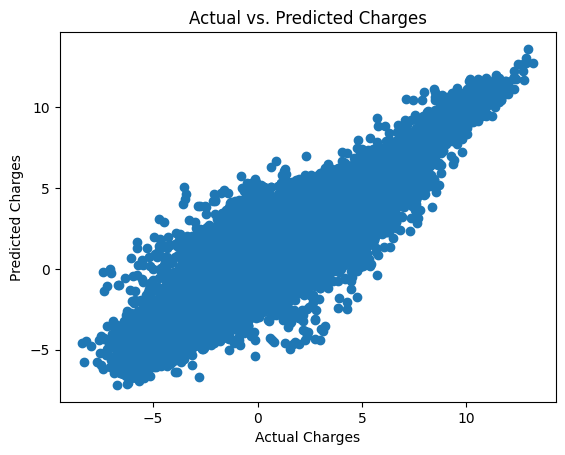

In [79]:
plt.scatter(y_test, prediction)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Charges')

**RANKING**

Here, I have tried to rank effective drugs for a particular cancer cell line. (This ranking is not biologically significant)

In [80]:
kf=KFold(n_splits=5, shuffle=True, random_state=42)
preds=cross_val_predict(model_linear, X, y, cv=kf, n_jobs=-1)

ranking_df=pd.DataFrame({"CELL_LINE_NAME": X["CELL_LINE_NAME"].values,
    "DRUG_NAME": X["DRUG_NAME"].values,
    "Actual_LN_IC50":y.values,
    "Predicted_LN_IC50":preds
})
ranking_df.head()


,CELL_LINE_NAME,DRUG_NAME,Actual_LN_IC50,Predicted_LN_IC50
0,PFSK-1,Camptothecin,-1.463887,-2.571393
1,A673,Camptothecin,-4.869455,-2.990357
2,ES5,Camptothecin,-3.360586,-3.020867
3,ES7,Camptothecin,-5.044940,-3.161987
4,EW-11,Camptothecin,-3.741991,-2.473403


In [81]:
ranking_df["Actual_Rank"] = ranking_df.groupby("CELL_LINE_NAME")["Actual_LN_IC50"].rank(method="min", ascending=True)
ranking_df["Predicted_Rank"] = ranking_df.groupby("CELL_LINE_NAME")["Predicted_LN_IC50"].rank(method="min", ascending=True)
ranking_df=ranking_df.sort_values(
    by=["Actual_Rank", "Predicted_Rank"],
    ascending=[True, True])
ranking_df

,CELL_LINE_NAME,DRUG_NAME,Actual_LN_IC50,Predicted_LN_IC50,Actual_Rank,Predicted_Rank
25271,RH-18,Staurosporine,-3.886978,-2.776235,1.0,1.0
66723,SK-N-FI,Bortezomib,-4.804344,-4.431957,1.0,1.0
66730,NCI-H2030,Bortezomib,-4.847620,-4.627081,1.0,1.0
66734,T24,Bortezomib,-4.436010,-3.808759,1.0,1.0
66764,BB65-RCC,Bortezomib,-5.530100,-4.526369,1.0,1.0
...,...,...,...,...,...,...
241429,HT-29,N-acetyl cysteine,10.242153,9.745676,294.0,294.0
241447,SW620,N-acetyl cysteine,9.958651,10.627958,294.0,294.0
240712,SW620,alpha-lipoic acid,10.134473,8.271880,295.0,292.0
239212,PC-14,ascorbate (vitamin C),10.648726,10.206870,295.0,295.0


In [88]:
min_drug=5
#spearman correlation between actual and predicted values for each cell line

def cell_line_corr(group):
    if len(group)<min_drug:
        return pd.Series({"n_drugs":len(group), "spearman_r":np.nan, "p_value":np.nan})
    r, p=spearmanr(group["Actual_LN_IC50"], group["Predicted_LN_IC50"])
    return pd.Series({"n_drugs": len(group), "spearman_r":r, "p_value":p}) #n_drugs=no.of drugs tested on this cell line

cell_line_spear=ranking_df.groupby("CELL_LINE_NAME").apply(cell_line_corr).dropna()
cell_line_spear=cell_line_spear.sort_values("spearman_r", ascending=False)
cell_line_spear.head(10)

/tmp/ipykernel_3327/2630588164.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_line_spear=ranking_df.groupby("CELL_LINE_NAME").apply(cell_line_corr).dropna()


,n_drugs,spearman_r,p_value
CELL_LINE_NAME,,,
RH-18,12.0,0.951049,2.038425e-06
NCI-H1792,280.0,0.928109,2.647764e-121
SJSA-1,170.0,0.928048,5.782100e-74
NCI-H2009,169.0,0.927885,1.867759e-73
HO-1-N-1,279.0,0.926078,2.923369e-119
Detroit562,279.0,0.925736,5.410553e-119
SNU-C5,280.0,0.922892,3.095288e-117
CAL-29,279.0,0.921830,4.967091e-116
HCC202,14.0,0.920879,2.981543e-06


Cell lines evaluated: 969
Mean Spearman correlation: 0.8443789133559304
Median Spearman correlation: 0.8505630518626575


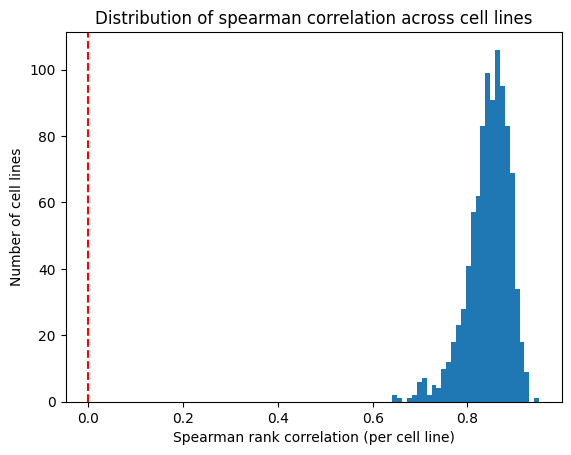

In [85]:
print("Cell lines evaluated:",len(cell_line_spear))
print("Mean Spearman correlation:",cell_line_spear["spearman_r"].mean())
print("Median Spearman correlation:",cell_line_spear["spearman_r"].median())

plt.hist(cell_line_spear["spearman_r"], bins=30)
plt.xlabel("Spearman rank correlation (per cell line)")
plt.ylabel("Number of cell lines")
plt.title("Distribution of spearman correlation across cell lines")
plt.axvline(0, color="red", linestyle="--")
plt.show()

In [89]:
# measure of how well predicted top k drugs match the actual top k drugs
def top_k_overlap(group, k=5):
    if len(group)<k:
        return np.nan
    actual_top=set(group.nsmallest(k, "Actual_LN_IC50")["DRUG_NAME"])
    predicted_top=set(group.nsmallest(k, "Predicted_LN_IC50")["DRUG_NAME"])
    return len(actual_top & predicted_top)/k
k=5
overlap_scores=ranking_df.groupby("CELL_LINE_NAME").apply(top_k_overlap, k=k).dropna()
print(f"Mean top-{k} overlap across cell lines:", overlap_scores.mean())
print(f"Median top-{k} overlap across cell lines:", overlap_scores.median())

Mean top-5 overlap across cell lines: 0.580185758513932
Median top-5 overlap across cell lines: 0.6


/tmp/ipykernel_3327/4172208277.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overlap_scores=ranking_df.groupby("CELL_LINE_NAME").apply(top_k_overlap, k=k).dropna()


In [95]:
#Testing with one cell line
def drug_ranking():
    test_cell_line = input("Enter cell line name: ").strip()

    rank_chart = (ranking_df[ranking_df["CELL_LINE_NAME"].str.lower() == test_cell_line.lower()]
        .sort_values("Actual_Rank")[["DRUG_NAME", "Actual_LN_IC50", "Predicted_LN_IC50","Actual_Rank", "Predicted_Rank"]].reset_index(drop=True))

    if rank_chart.empty:
        print(f"No ranking data found for cell line: {test_cell_line}")
        return

    print(f"Cell line: {test_cell_line}")
    return rank_chart

ranks=drug_ranking()
print(ranks.to_string(index=False))

Enter cell line name: rh-18
Cell line: rh-18
            DRUG_NAME  Actual_LN_IC50  Predicted_LN_IC50  Actual_Rank  Predicted_Rank
        Staurosporine       -3.886978          -2.776235          1.0             1.0
         Camptothecin       -1.072759          -2.469805          2.0             2.0
               MG-132       -0.529618          -1.595361          3.0             3.0
            PD0325901        2.032042           1.368438          4.0             4.0
               NU7441        2.876935           3.117733          5.0             6.0
             SB590885        2.941451           4.361586          6.0             8.0
             ZM447439        3.247868           2.190467          7.0             5.0
             EHT-1864        3.892485           3.290411          8.0             7.0
            CCT007093        4.966422           5.156114          9.0            10.0
          Avagacestat        5.456548           4.833836         10.0             9.0
ascorbate